In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [2]:
df = pd.read_csv("../data/processed/hdfc_top100_nav_clean.csv")

df['date'] = pd.to_datetime(df['date'])

df.head()

,date,nav
0,2013-11-18,13.0894
1,2013-11-19,13.1068
2,2013-11-20,12.9549
3,2013-11-21,12.7957
4,2013-11-22,12.7775


In [3]:
df.columns

Index(['date', 'nav'], dtype='object')

In [4]:
daily_return = nav_t/nav_t-1 - 1

NameError: name 'nav_t' is not defined

In [5]:
daily_return = nav_t/nav_t-1 - 1

NameError: name 'nav_t' is not defined

In [6]:
Index(['date', 'nav'], dtype='object')

NameError: name 'Index' is not defined

In [7]:
df['daily_return'] = df['nav'].pct_change()

In [8]:
df['daily_return'] = df['nav'] / df['nav'].shift(1) - 1

In [9]:
df.head()

,date,nav,daily_return
0,2013-11-18,13.0894,NaN
1,2013-11-19,13.1068,0.001329
2,2013-11-20,12.9549,-0.011589
3,2013-11-21,12.7957,-0.012289
4,2013-11-22,12.7775,-0.001422


In [10]:
df['daily_return'].describe()

count    3090.000000
mean        0.000916
std         0.009583
min        -0.096964
25%        -0.003345
50%         0.001493
75%         0.006257
max         0.046026
Name: daily_return, dtype: float64

In [11]:
date
nav

NameError: name 'date' is not defined

In [12]:
date

NameError: name 'date' is not defined

In [13]:
df.head()

,date,nav,daily_return
0,2013-11-18,13.0894,NaN
1,2013-11-19,13.1068,0.001329
2,2013-11-20,12.9549,-0.011589
3,2013-11-21,12.7957,-0.012289
4,2013-11-22,12.7775,-0.001422


In [14]:
df.columns

Index(['date', 'nav', 'daily_return'], dtype='object')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3091 entries, 0 to 3090
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          3091 non-null   datetime64[ns]
 1   nav           3091 non-null   float64       
 2   daily_return  3090 non-null   float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 72.6 KB


In [16]:
len(df)

3091

In [17]:
df.head()

,date,nav,daily_return
0,2013-11-18,13.0894,NaN
1,2013-11-19,13.1068,0.001329
2,2013-11-20,12.9549,-0.011589
3,2013-11-21,12.7957,-0.012289
4,2013-11-22,12.7775,-0.001422


In [18]:
len(df)

3091

In [19]:
def calculate_cagr(nav_start, nav_end, years):
    return (nav_end / nav_start) ** (1 / years) - 1

In [20]:
end_nav = df.iloc[-1]['nav']

start_date = df['date'].max() - pd.DateOffset(years=1)

start_nav = df[df['date'] >= start_date].iloc[0]['nav']

cagr_1y = calculate_cagr(start_nav, end_nav, 1)

print("1-Year CAGR:", cagr_1y)

1-Year CAGR: -0.0035987008203027804


In [21]:
start_date = df['date'].max() - pd.DateOffset(years=3)

start_nav = df[df['date'] >= start_date].iloc[0]['nav']

cagr_3y = calculate_cagr(start_nav, end_nav, 3)

print("3-Year CAGR:", cagr_3y)

3-Year CAGR: 0.13270595665203389


In [22]:
start_date = df['date'].max() - pd.DateOffset(years=5)

start_nav = df[df['date'] >= start_date].iloc[0]['nav']

cagr_5y = calculate_cagr(start_nav, end_nav, 5)

print("5-Year CAGR:", cagr_5y)

5-Year CAGR: 0.14621867356128737


In [23]:
RF = 0.065

annual_return = df['daily_return'].mean() * 252

annual_volatility = df['daily_return'].std() * np.sqrt(252)

sharpe = (annual_return - RF) / annual_volatility

print("Sharpe Ratio:", sharpe)

Sharpe Ratio: 1.0905104257321683


In [24]:
downside_returns = df[df['daily_return'] < 0]['daily_return']

downside_std = downside_returns.std() * np.sqrt(252)

sortino = (annual_return - RF) / downside_std

print("Sortino Ratio:", sortino)

Sortino Ratio: 1.3199787084615837


In [25]:
df['running_max'] = df['nav'].cummax()

df['drawdown'] = df['nav'] / df['running_max'] - 1

max_dd = df['drawdown'].min()

print("Maximum Drawdown:", max_dd)|

SyntaxError: invalid syntax (622149686.py, line 7)

In [26]:
df['running_max'] = df['nav'].cummax()

df['drawdown'] = df['nav'] / df['running_max'] - 1

max_dd = df['drawdown'].min()

print("Maximum Drawdown:", max_dd)

Maximum Drawdown: -0.4026012761687717


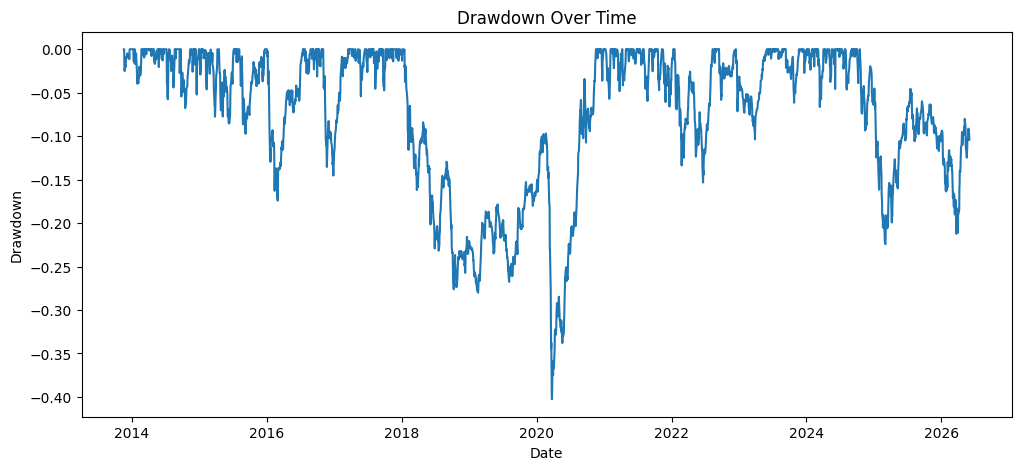

In [27]:
plt.figure(figsize=(12,5))

plt.plot(df['date'], df['drawdown'])

plt.title("Drawdown Over Time")

plt.xlabel("Date")

plt.ylabel("Drawdown")

plt.show()

In [28]:
results = pd.DataFrame({
    'Metric': [
        '3Y CAGR',
        '5Y CAGR',
        'Sharpe Ratio',
        'Sortino Ratio',
        'Maximum Drawdown'
    ],
    'Value': [
        cagr_3y,
        cagr_5y,
        sharpe,
        sortino,
        max_dd
    ]
})

results

,Metric,Value
0,3Y CAGR,0.132706
1,5Y CAGR,0.146219
2,Sharpe Ratio,1.090510
3,Sortino Ratio,1.319979
4,Maximum Drawdown,-0.402601


In [29]:
results.to_csv(
    '../reports/fund_scorecard.csv',
    index=False
)

In [30]:
import os

print(os.listdir('../reports'))

['data_dictionary.md', 'fund_scorecard.csv', 'monthly_nav.png', 'nav_trend.png', 'return_distribution.png', 'rolling_average.png', 'yearly_nav.png']
